## **2D Ising Model on GPU(NVidia Warp)**

## Warp Installation

In [1]:
try:
  import warp as wp
  print(f"Warp version {wp.__version__} is ready!")
except ImportError:
  print("Warp not found. Installing...")
  !pip install warp-lang #It will install if not installed
  import warp as wp

Warp not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 MB 7.0 MB/s eta 0:00:00


##GPU Specifications

In [2]:
wp.init()
device = wp.get_device("cuda")
print("Name:", device.name)
print("Memory (GB):", device.total_memory/(1024**3)) #RAM in GB
print("Is CUDA:", device.is_cuda)

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.12.0
Name: Tesla T4
Memory (GB): 14.56317138671875
Is CUDA: True


**Spin Initialization**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
def spin_init(L):
  spin = np.random.choice([np.int8(1), np.int8(-1)], (L, L)) #random initial spin

  return spin, wp.array(spin, dtype = wp.int8)

## Spin update

In [4]:
wp.init()
@wp.kernel
def spin_update_wp(spin: wp.array2d(dtype = wp.int8),
                   T: wp.float32,
                   seed: int,
                   color: int):
  L = len(spin[0])
  x, y = wp.tid()
  if (x + y)%2 == color: #either for odd or even positioned spin
    s = spin[x, y]
    nb_sum = spin[(x + 1)%L, y] + spin[(x - 1)%L, y] + spin[x, (y + 1)%L] + spin[x, (y - 1)%L]
    delta_e = 2.0*float(s*nb_sum)
    state = wp.rand_init(seed, x*L + y)
    if delta_e <= 0.0 or wp.randf(state) < wp.exp(-delta_e/T):
      spin[x, y] = -s

In [45]:
import time
L_f = 8192
spin = spin_init(L_f)[-1]
wp.synchronize()
start = time.time()
T = 2.269
seed0 = np.random.randint(0, 10000)
seed1 = np.random.randint(0, 10000)
wp.launch(spin_update_wp, dim=(L_f, L_f), inputs=[spin, T, seed0, 0])
wp.launch(spin_update_wp, dim=(L_f, L_f), inputs=[spin, T, seed1, 1])

wp.synchronize()

end = time.time()

elapsed = end - start

## GPU Flops Calculation

In [46]:
flops = 5 * (L_f**2)
flops_per_sec = flops / elapsed

print("FLOPS =", flops_per_sec / 1e9, "GFLOPS")

FLOPS = 19.524636990556314 GFLOPS


In [21]:
import numpy as np

def spin_update_np(spin, T, color):

  L = spin.shape[0]
  nb_sum = (
        np.roll(spin, 1, axis=0) +
        np.roll(spin, -1, axis=0) +
        np.roll(spin, 1, axis=1) +
        np.roll(spin, -1, axis=1)) #sum of neighbouring spin

  delta_E = 2 * spin * nb_sum
  x = np.arange(L)
  y = np.arange(L)
  X, Y = np.meshgrid(x, y, indexing='ij')
  mask = (X + Y) % 2 == color

  rand = np.random.rand(L, L)
  accept = (delta_E <= 0) | (rand < np.exp(-delta_E / T))

  flip = mask & accept #flip for either  odd or even positioned spin

  spin[flip] *= -1

  return spin

In [22]:
L_list  = [32, 64, 128, 256, 512, 1024]
T_np, T_wp = [], []
T_ratio = []
for L in L_list:
  spin_np, spin_wp = spin_init(L)
  N_iter = 400
  t1 = time.time()
  for i in range(N_iter):
    spin_update_np(spin_np, 2.269, 0)
    spin_update_np(spin_np, 2.269, 1)
    t2 = time.time()
  t_np = t2 - t1
  t3 = time.time()
  wp.synchronize()
  for i in range(N_iter):
    seed = int(time.time())
    wp.launch(spin_update_wp, dim = (L, L), inputs = (spin_wp, 2.269, seed, 0))
    wp.launch(spin_update_wp, dim = (L, L), inputs = (spin_wp, 2.269, seed, 1))
    wp.synchronize()
    t4 = time.time()
    t_wp = t4 - t3
  T_ratio.append(t_np/t_wp) #Performance ratio for different lattice sizes

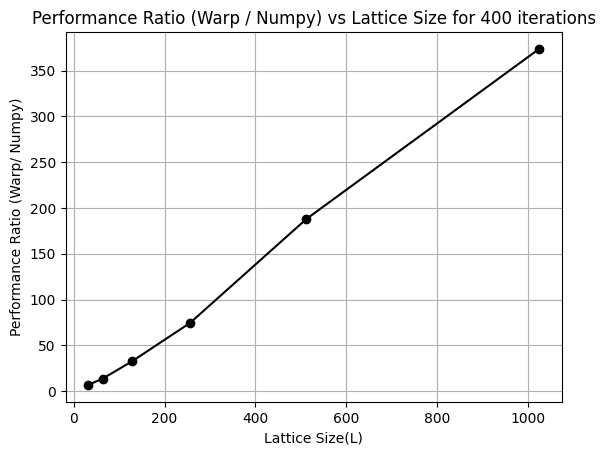

In [23]:
plt.plot(L_list, T_ratio, marker = 'o', color = 'black')
plt.xlabel("Lattice Size(L)")
plt.ylabel("Performance Ratio (Warp/ Numpy)")
plt.title(f"Performance Ratio (Warp / Numpy) vs Lattice Size for {N_iter} iterations")
plt.grid()
plt.show()

In [43]:
for i in range(len(L_list)):
  print(f"Speed up for lattice size  {L_list[i]} =",T_ratio[i])

Speed up for lattice size  32 = 6.854470016351684
Speed up for lattice size  64 = 13.762532125658108
Speed up for lattice size  128 = 32.48218167841743
Speed up for lattice size  256 = 74.4760059777495
Speed up for lattice size  512 = 187.93965764731215
Speed up for lattice size  1024 = 373.55540926180987


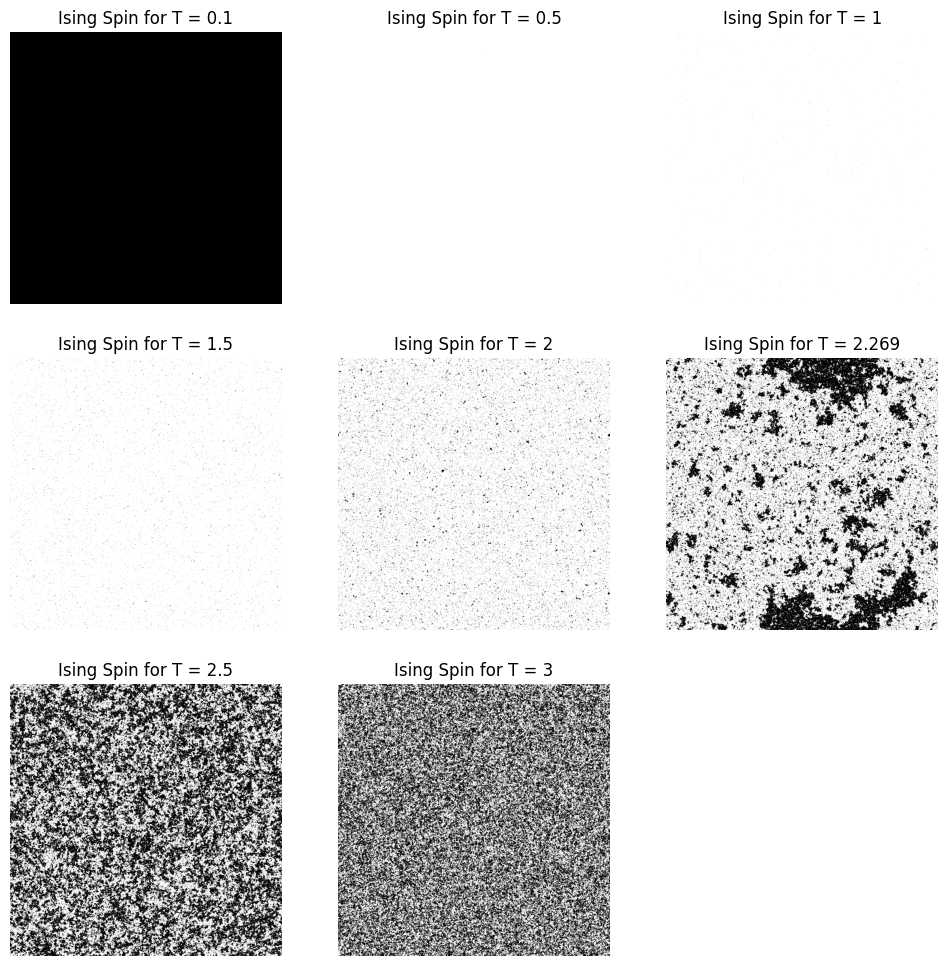

In [44]:
T_val = [0.1, 0.5, 1, 1.5, 2, 2.269, 2.5, 3]
e = 1
plt.figure(figsize = (12, 12))
N_iter = 20000
L_wp = 1024
spin = spin_init(L_wp)[-1]
seed0 = np.random.randint(0, 100000)
seed1 = np.random.randint(0, 100000)
for T in T_val:
  for i in range(N_iter):
    wp.launch(spin_update_wp,
          dim= (L_wp, L_wp),
          inputs=[spin, T, seed0 + i, 0])
    wp.launch(spin_update_wp,
          dim= (L_wp, L_wp),
          inputs=[spin, T, seed1 + i, 1])
  spin_new = spin.numpy()
  plt.subplot(3, 3, e)
  e += 1
  plt.imshow(spin_new, cmap = 'gray')
  plt.title(f"Ising Spin for T = {T}")
  plt.axis('off')
plt.show()

In [26]:
def Magnetization(spin, T, N_eq, N_monte):
  L = spin.shape[0]
  for _ in range(N_eq):
      seed0 = int(np.random.randint(0, 10000))
      seed1 = int(np.random.randint(0, 10000))
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed0, 0])
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed1, 1])
  M_list = []

  for _ in range(N_monte):
      seed0 = int(np.random.randint(0, 10000))
      seed1 = int(np.random.randint(0, 10000))
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed0, 0])
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed1, 1])
      spin_np = spin.numpy()
      M = np.mean(spin_np)

      M_list.append(abs(M))
  return np.abs(np.mean(M_list))

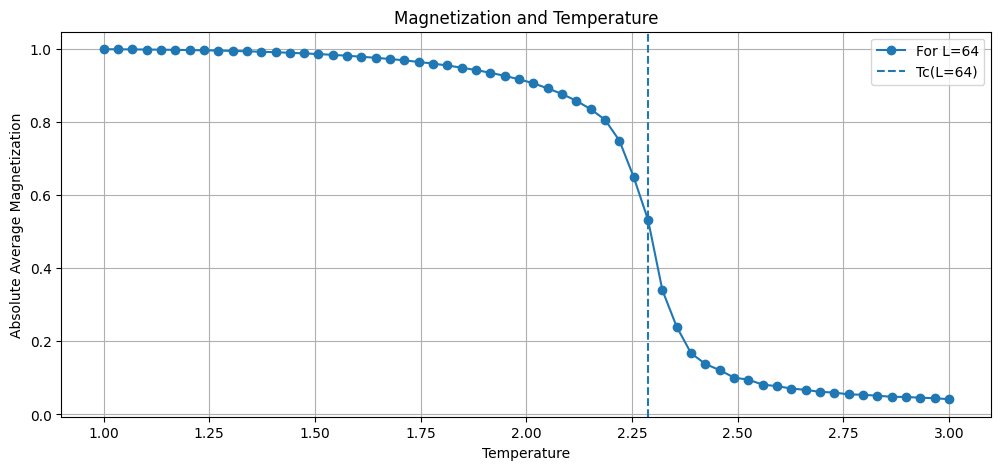

In [27]:
L_cal = 64
T_list = np.linspace(1, 3, 60)
TC = []
M_2d = np.zeros(len(T_list))
plt.figure(figsize = (12, 5))
for j in range(len(T_list)):
  T = T_list[j]
  spin = spin_init(L_cal)[-1]
  m = Magnetization(spin, T, 20000, 10000)
  M_2d[j] = m
dM_dT = np.gradient(M_2d, T_list)
Tc_L = T_list[np.argmin(dM_dT)]
TC.append(Tc_L)
plt.plot(T_list, M_2d, marker='o', label=f'For L={L_cal}')
plt.axvline(Tc_L, linestyle='--', label=f'Tc(L={L_cal})')
plt.xlabel("Temperature")
plt.ylabel("Absolute Average Magnetization")
plt.grid()
plt.legend()
plt.title("Magnetization and Temperature")
plt.show()

In [28]:
print("Critical Temperature for lattice size 64 = ", TC)

Critical Temperature for lattice size 64 =  [np.float64(2.288135593220339)]


In [29]:
e = 0
eps = 0.02
for tc in TC:
  mask =  (T_list < tc - eps) & (T_list > 2)
  x = np.log(tc - T_list[mask])
  y = np.log(M_2d[mask])
  beta = np.polyfit(x, y, 1)[0]
  e += 1
  print(beta)

0.1569746714835105


In [33]:
print(r"Critical Exponent for Magnetization beta = ",beta)

Critical Exponent for Magnetization beta=  0.1569746714835105


In [34]:
wp.init()
@wp.kernel
def Energy(spin: wp.array2d(dtype = wp.int8),
           E: wp.array2d(dtype = wp.int8),
           T: float):
  L = spin.shape[0]
  x, y = wp.tid()
  if (x + y)%2 == 0:
    s = spin[x, y]
    nb_sum =spin[(x + 1)%L, y] + spin[(x - 1)%L, y] + spin[x, (y + 1)%L] + spin[x, (y - 1)%L]
    E[x, y] = -s*nb_sum
  elif (x + y)%2 == 1:
    s = spin[x, y]
    nb_sum = spin[(x + 1)%L, y] + spin[(x - 1)%L, y] + spin[x, (y + 1)%L] + spin[x, (y - 1)%L]
    E[x, y] = -s*nb_sum

In [35]:
def Energy_av(spin, T, N_eq, N_monte):
  L = len(spin[0])
  for i in range(N_eq):
      seed0 = np.random.randint(0, 10000)
      seed1 = int(np.random.randint(0, 10000))
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed0, 0])
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed1, 1])
  E_list = []
  E2_list = []
  E = wp.zeros((L, L), dtype = wp.int8)
  for j in range(N_monte):
      seed0 = int(np.random.randint(0, 10000))
      seed1 = int(np.random.randint(0, 10000))
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed0, 0])
      wp.launch(spin_update_wp, dim=(L, L), inputs=[spin, T, seed1, 1])
      wp.launch(Energy, dim = (L, L), inputs = [spin, E, T])
      E_np = E.numpy()/4
      E_list.append(np.mean(E_np))
      E2_list.append(np.mean(E_np**2))
  return np.mean(E_list), np.mean(E2_list)

In [36]:
L = 64
E_T = []
C_T = []
Tnew_list = np.linspace(1, 4, 60)
for T in Tnew_list:
  spin = spin_init(L)[-1]
  e,e2 = Energy_av(spin, T, 12000, 10000)
  E_T.append(e)
  C_T.append((e2 - e**2)/T**2)

Module __main__ 2cb1feb load on device 'cuda:0' took 285.78 ms  (compiled)


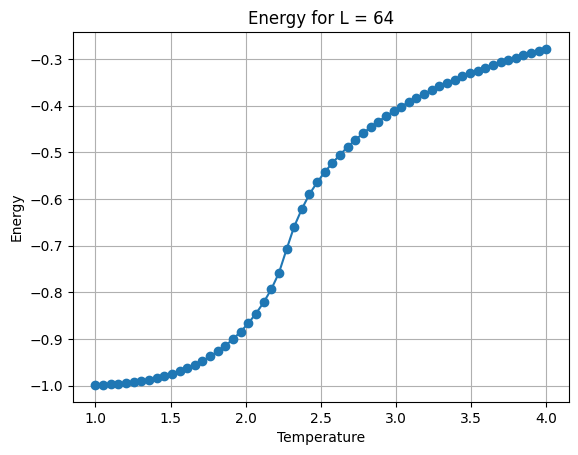

In [41]:
plt.plot(Tnew_list, E_T, marker = 'o')
plt.xlabel("Temperature")
plt.ylabel("Energy")
plt.title(f"Energy for L = {L}")
plt.grid()
plt.show()

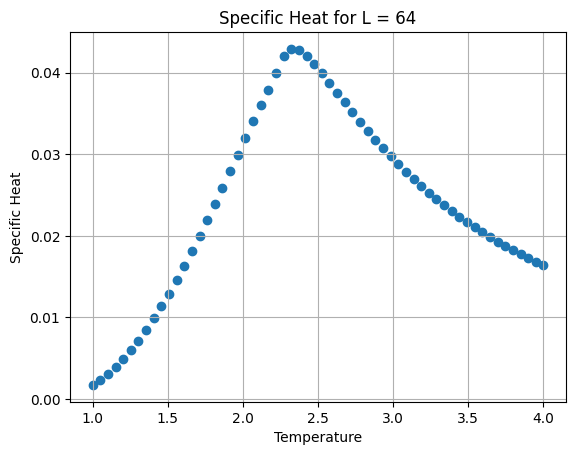

In [42]:
plt.scatter(Tnew_list, C_T)
plt.xlabel("Temperature")
plt.ylabel("Specific Heat")
plt.title(f"Specific Heat for L = {L}")
plt.grid()
plt.show()